# Housing Price Prediction — Improved Model Development

This notebook improves upon the baseline KNN model in `create_model.py` by:
- Conducting exploratory data analysis (EDA)
- Engineering new features from available columns
- Training and comparing multiple regression models
- Evaluating models by RMSE, training time, and prediction time

In [2]:
%matplotlib inline
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

SALES_PATH = '../data/kc_house_data.csv'
DEMOGRAPHICS_PATH = '../data/zipcode_demographics.csv'
RANDOM_STATE = 42

---
# 1. Exploratory Data Analysis

## 1.1 Load raw data

In [3]:
sales = pd.read_csv(SALES_PATH, dtype={'zipcode': str})
demographics = pd.read_csv(DEMOGRAPHICS_PATH, dtype={'zipcode': str})

print('Sales shape:', sales.shape)
print('Demographics shape:', demographics.shape)
sales.head()

Sales shape: (21613, 21)
Demographics shape: (70, 27)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  object 
 17  lat            21613 non-null  float64
 18  long  

In [5]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


## 1.2 Missing values

In [6]:
missing = sales.isna().sum()
print('Missing values in sales data:')
print(missing[missing > 0] if missing.any() else 'None')

missing_demo = demographics.isna().sum()
print('\nMissing values in demographics:')
print(missing_demo[missing_demo > 0] if missing_demo.any() else 'None')

Missing values in sales data:
None

Missing values in demographics:
None


## 1.3 Target variable — Price distribution

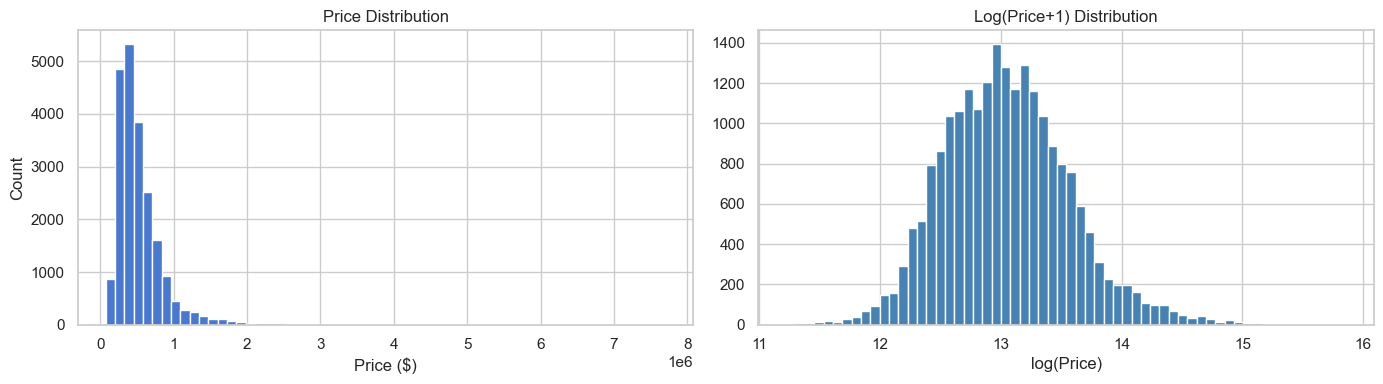

Skewness (raw): 4.02
Skewness (log): 0.43


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sales['price'], bins=60, edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(sales['price']), bins=60, edgecolor='white', color='steelblue')
axes[1].set_title('Log(Price+1) Distribution')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {sales['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(sales['price']).skew():.2f}")

The price distribution is right-skewed. A log transform makes it more symmetric,
which benefits linear models. We train Ridge on log-price and inverse-transform predictions.

## 1.4 Numerical feature distributions

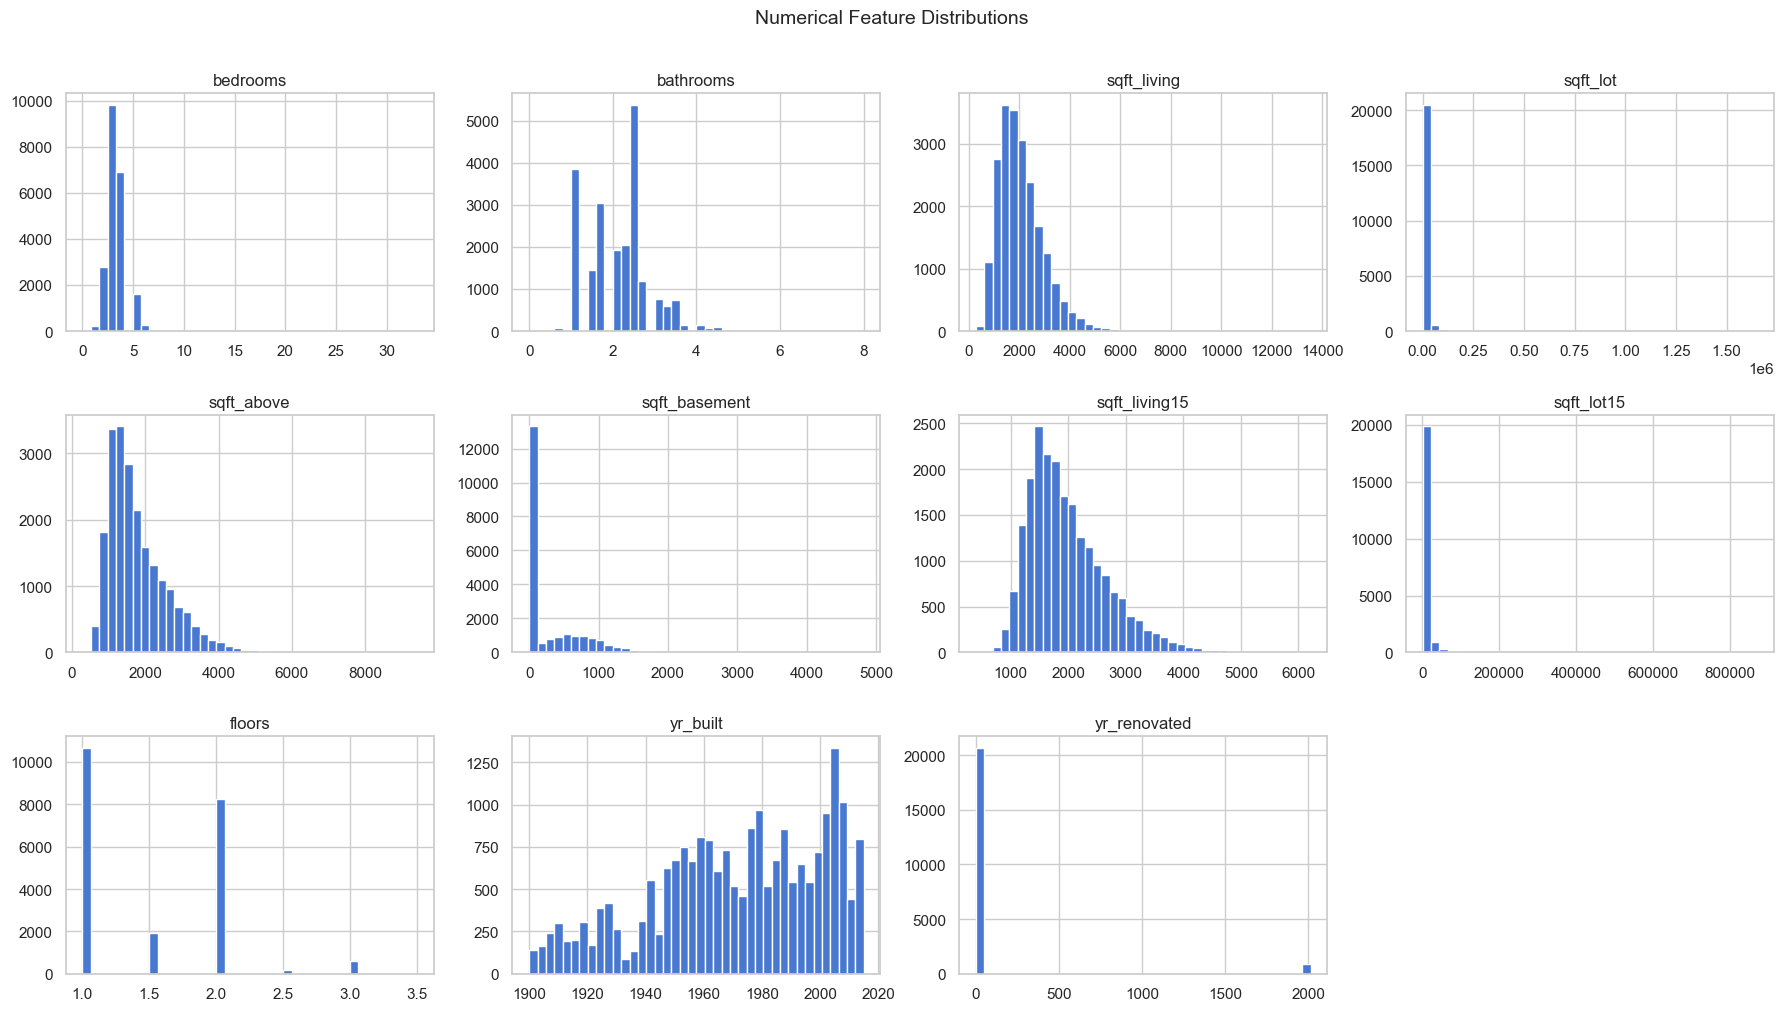

In [8]:
num_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15',
                'floors', 'yr_built', 'yr_renovated']

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(sales[col].dropna(), bins=40, edgecolor='white')
    axes[i].set_title(col)

for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.5 Categorical / ordinal feature distributions

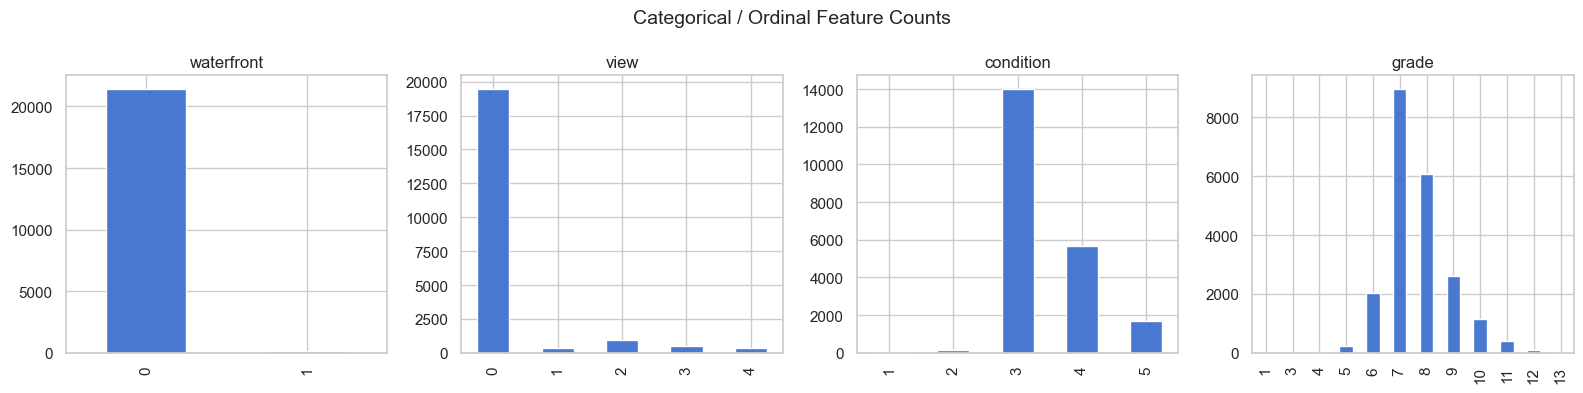

In [9]:
cat_features = ['waterfront', 'view', 'condition', 'grade']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_features):
    vc = sales[col].value_counts().sort_index()
    vc.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Categorical / Ordinal Feature Counts', fontsize=14)
plt.tight_layout()
plt.show()

## 1.6 Correlation with price

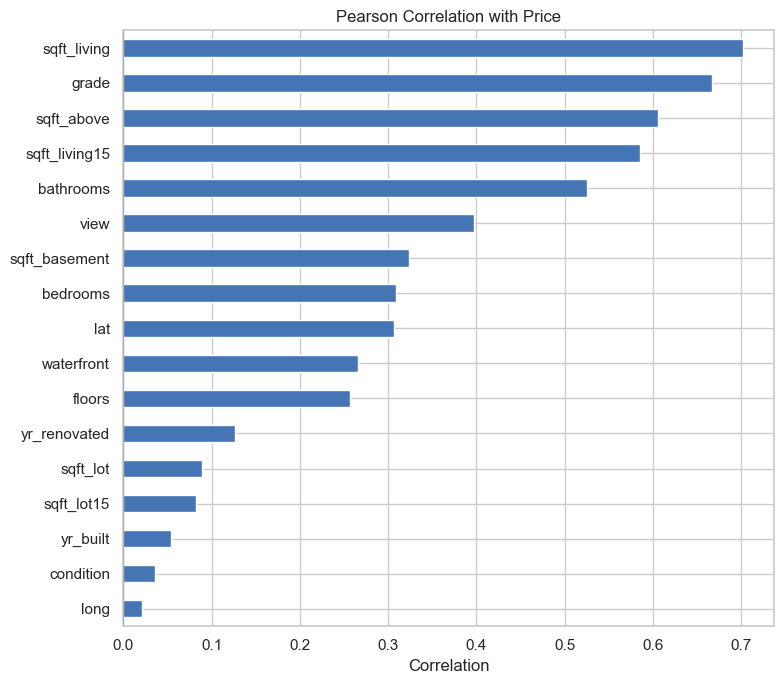

In [10]:
numeric_cols = sales.select_dtypes(include='number').columns.drop(['id'])
correlations = sales[numeric_cols].corr()['price'].drop('price').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d73027' if c < 0 else '#4575b4' for c in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Price')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

## 1.7 Price vs key features (scatter)

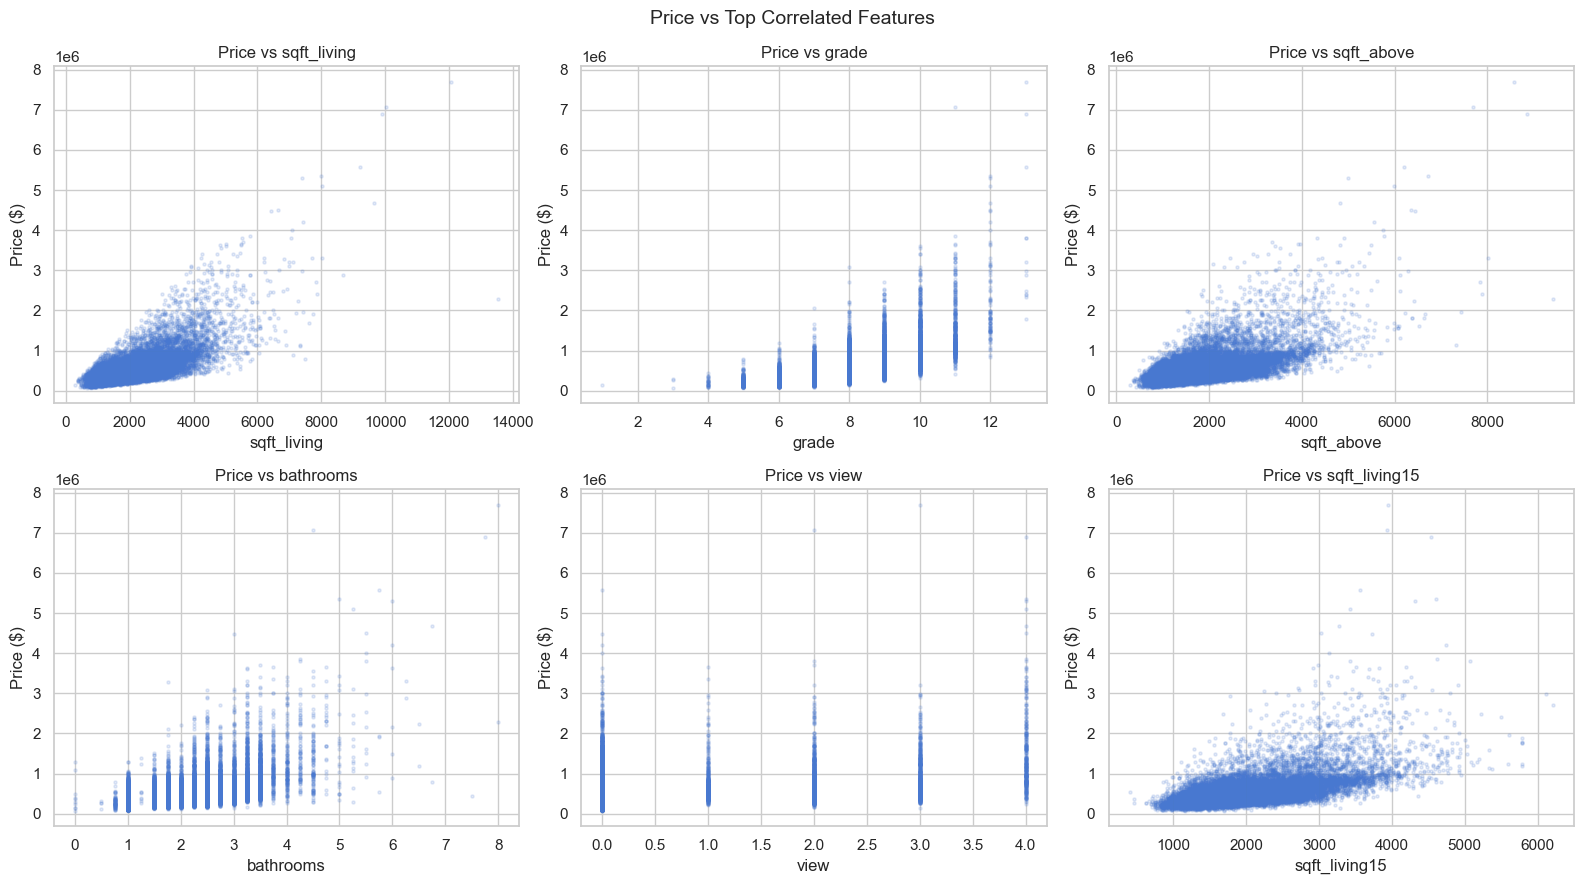

In [11]:
top_features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'view', 'sqft_living15']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    ax.scatter(sales[col], sales['price'], alpha=0.15, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'Price vs {col}')

plt.suptitle('Price vs Top Correlated Features', fontsize=14)
plt.tight_layout()
plt.show()

## 1.8 Price by waterfront and view

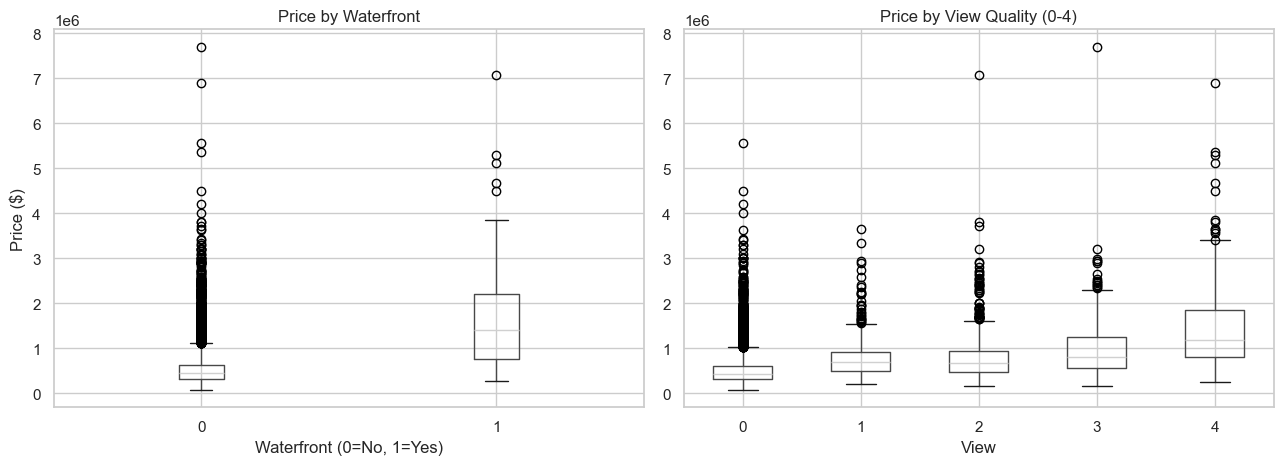

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sales.boxplot(column='price', by='waterfront', ax=axes[0])
axes[0].set_title('Price by Waterfront')
axes[0].set_xlabel('Waterfront (0=No, 1=Yes)')
axes[0].set_ylabel('Price ($)')

sales.boxplot(column='price', by='view', ax=axes[1])
axes[1].set_title('Price by View Quality (0-4)')
axes[1].set_xlabel('View')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 1.9 Geographic price distribution (lat / long)

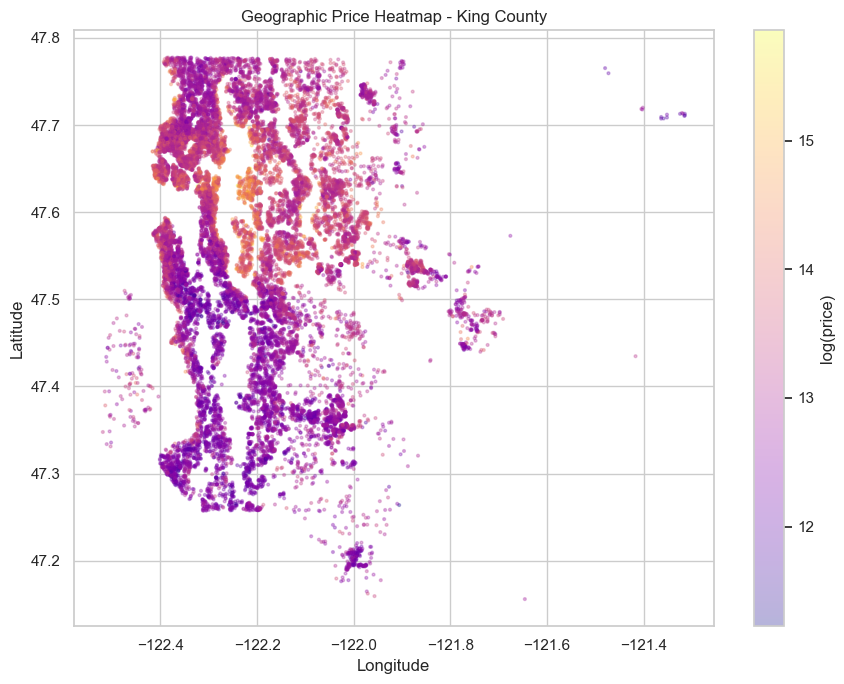

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(sales['long'], sales['lat'],
                c=np.log1p(sales['price']), cmap='plasma',
                alpha=0.3, s=4)
plt.colorbar(sc, ax=ax, label='log(price)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Price Heatmap - King County')
plt.tight_layout()
plt.show()

In [14]:
import plotly.express as px
import requests

# Average price per ZIP code
zip_price = (
    sales.groupby('zipcode')['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price'})
)

# Washington ZIP code boundaries — public GeoJSON, filtered to King County ZIPs
url = ('https://raw.githubusercontent.com/OpenDataDE/'
       'State-zip-code-GeoJSON/master/wa_washington_zip_codes_geo.min.json')
wa_geojson = requests.get(url).json()

king_zips = set(sales['zipcode'].unique())
wa_geojson['features'] = [
    f for f in wa_geojson['features']
    if f['properties']['ZCTA5CE10'] in king_zips
]

fig = px.choropleth(
    zip_price,
    geojson=wa_geojson,
    locations='zipcode',
    featureidkey='properties.ZCTA5CE10',
    color='avg_price',
    color_continuous_scale='plasma',
    labels={'avg_price': 'Avg Price ($)'},
    title='Average House Price by ZIP Code — King County, WA',
)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    width=900,
    height=750,
    coloraxis_colorbar=dict(title='Avg Price ($)'),
)

fig.write_image('../images/king_county_choropleth.jpg', scale=2)
# fig.show()
print('Saved → ../images/king_county_choropleth.jpg')

Saved → ../images/king_county_choropleth.jpg


In [15]:
# Seattle city proper ZIP codes
SEATTLE_ZIPS = {
    '98101', '98102', '98103', '98104', '98105', '98106', '98107',
    '98108', '98109', '98112', '98115', '98116', '98117', '98118',
    '98119', '98121', '98122', '98125', '98126', '98133', '98134',
    '98136', '98144', '98146', '98154', '98164', '98174', '98177',
    '98178', '98195', '98199',
}

seattle_price = (
    sales[sales['zipcode'].isin(SEATTLE_ZIPS)]
    .groupby('zipcode')['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price'})
)

# Reuse the already-filtered WA GeoJSON, narrow to Seattle ZIPs
seattle_geojson = {
    'type': 'FeatureCollection',
    'features': [
        f for f in wa_geojson['features']
        if f['properties']['ZCTA5CE10'] in SEATTLE_ZIPS
    ]
}

fig_seattle = px.choropleth(
    seattle_price,
    geojson=seattle_geojson,
    locations='zipcode',
    featureidkey='properties.ZCTA5CE10',
    color='avg_price',
    color_continuous_scale='plasma',
    labels={'avg_price': 'Avg Price ($)'},
    title='Average House Price by ZIP Code — Seattle, WA',
)
fig_seattle.update_geos(fitbounds='locations', visible=False)
fig_seattle.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    width=900,
    height=750,
    coloraxis_colorbar=dict(title='Avg Price ($)'),
)

fig_seattle.write_image('../images/seattle_choropleth.jpg', scale=2)
# fig_seattle.show()
print('Saved → ../images/seattle_choropleth.jpg')

Saved → ../images/seattle_choropleth.jpg


## 1.10 Correlation heatmap (full feature set)

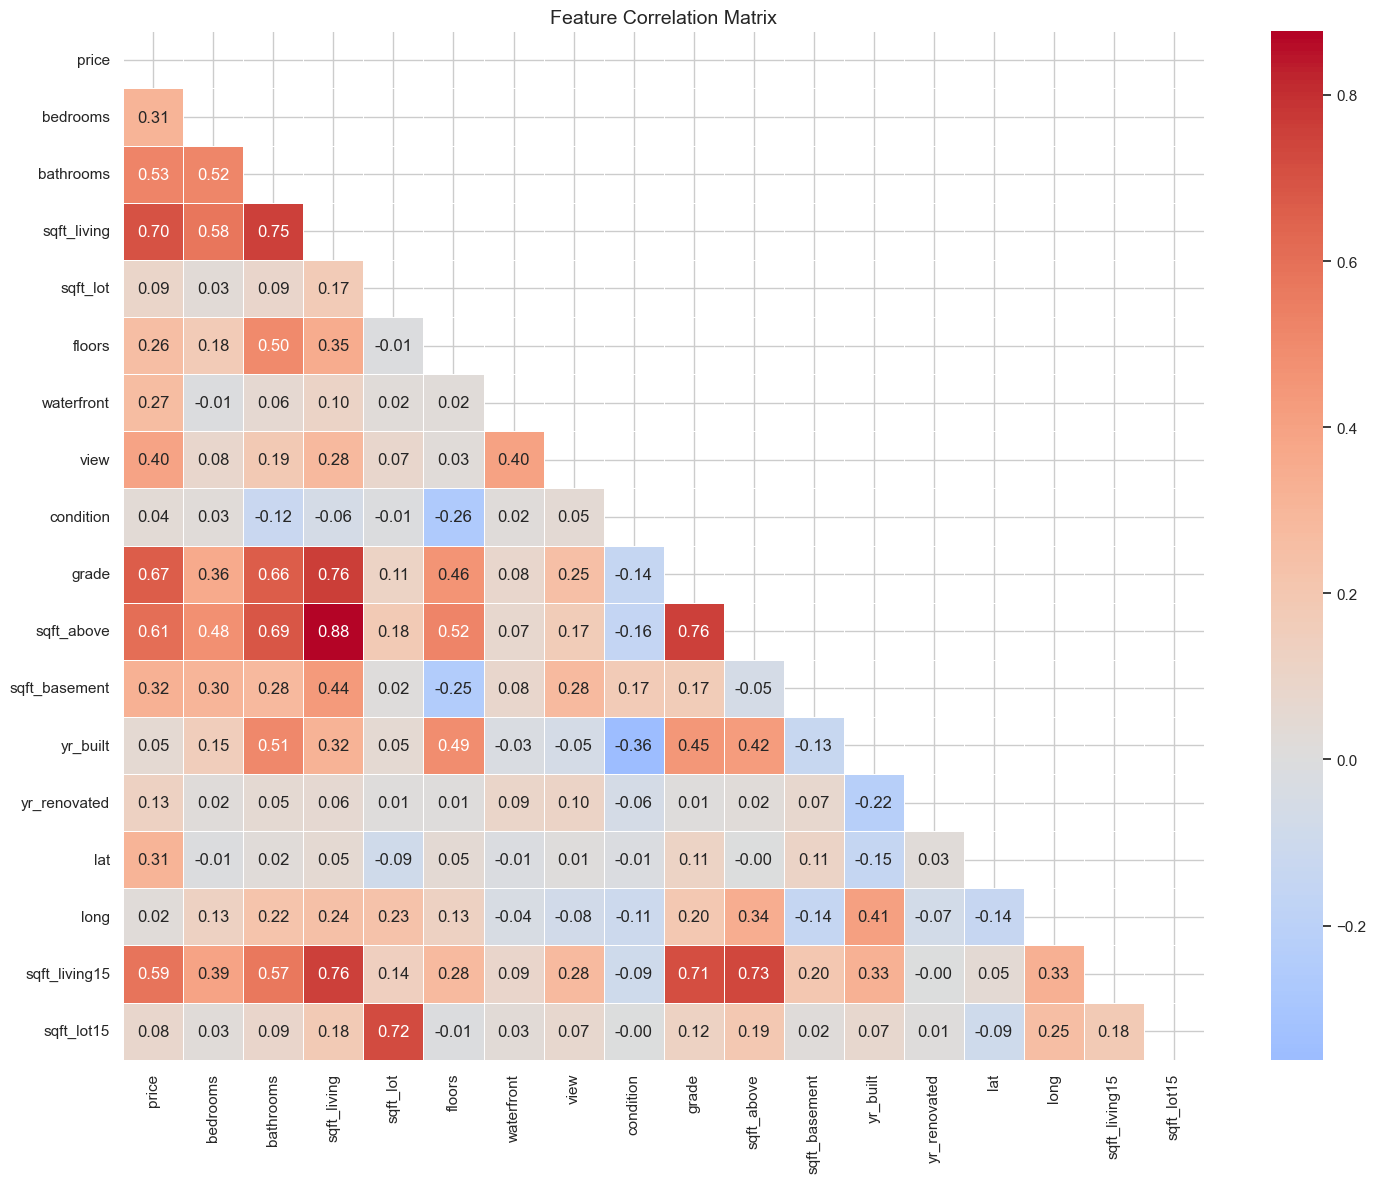

In [16]:
fig, ax = plt.subplots(figsize=(15, 12))
corr_matrix = sales[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

**Key EDA takeaways:**
- `sqft_living`, `grade`, and `sqft_above` are the strongest positive correlates with price.
- `waterfront` and `view` have a clear impact on price despite low frequency.
- `lat` / `long` encode neighbourhood effects — homes in the north-east cluster (Bellevue) are pricier.
- `yr_renovated` is mostly zero; a binary flag (`renovated`) is more informative.
- `sqft_living` and `sqft_above` are highly collinear — handled naturally by tree models or regularisation.
- **The baseline model ignores:** `waterfront`, `view`, `condition`, `grade`, `yr_built`, `lat`, `long`, `sqft_living15`, `sqft_lot15`.

---
# 2. Feature Engineering

In [17]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create new features from raw sales columns."""
    df = df.copy()

    sale_year = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S').dt.year

    # Age of the house at time of sale
    df['house_age'] = sale_year - df['yr_built']

    # Binary renovation flag (0/1)
    df['renovated'] = (df['yr_renovated'] > 0).astype(int)

    # Years since most recent update (renovation or original build)
    df['years_since_reno'] = np.where(
        df['yr_renovated'] > 0,
        sale_year - df['yr_renovated'],
        df['house_age']
    )

    # Basement presence flag
    df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

    # Living area relative to 15 nearest neighbours
    df['sqft_living_ratio'] = df['sqft_living'] / (df['sqft_living15'] + 1)

    # Lot size relative to 15 nearest neighbours
    df['sqft_lot_ratio'] = df['sqft_lot'] / (df['sqft_lot15'] + 1)

    # Bedroom-to-bathroom ratio
    df['bed_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 1)

    return df


sales_eng = engineer_features(sales)
new_cols = ['house_age', 'renovated', 'years_since_reno',
            'has_basement', 'sqft_living_ratio', 'sqft_lot_ratio', 'bed_bath_ratio']
print('Engineered features added:', new_cols)
sales_eng[new_cols].describe().T

Engineered features added: ['house_age', 'renovated', 'years_since_reno', 'has_basement', 'sqft_living_ratio', 'sqft_lot_ratio', 'bed_bath_ratio']


,count,mean,std,min,25%,50%,75%,max
house_age,21613.0,43.317818,29.375493,-1.000000,18.000000,40.000000,63.000000,115.000000
renovated,21613.0,0.042289,0.201253,0.000000,0.000000,0.000000,0.000000,1.000000
years_since_reno,21613.0,40.936936,28.813643,-1.000000,15.000000,37.000000,60.000000,115.000000
has_basement,21613.0,0.392680,0.488358,0.000000,0.000000,0.000000,1.000000,1.000000
sqft_living_ratio,21613.0,1.052341,0.320217,0.178902,0.880533,0.999504,1.160034,5.986985
sqft_lot_ratio,21613.0,1.133153,1.279857,0.054972,0.936913,0.999847,1.093177,87.519699
bed_bath_ratio,21613.0,1.111069,0.304124,0.000000,0.923077,1.090909,1.230769,12.000000


## 2.1 Merge demographics

In [18]:
data = sales_eng.merge(demographics, how='left', on='zipcode')
print('Shape after merging demographics:', data.shape)
print('Missing values after merge:', data.isna().sum().sum())

Shape after merging demographics: (21613, 54)
Missing values after merge: 0


## 2.2 Select final feature set

In [19]:
DROP_COLS = ['id', 'date', 'zipcode', 'price']

X = data.drop(columns=DROP_COLS)
y = data['price']
y_log = np.log1p(y)   # log-transformed target for Ridge

print('Feature matrix shape:', X.shape)
print('Features:', list(X.columns))

Feature matrix shape: (21613, 50)
Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'renovated', 'years_since_reno', 'has_basement', 'sqft_living_ratio', 'sqft_lot_ratio', 'bed_bath_ratio', 'ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl']


## 2.3 Train / Validation / Test split

In [20]:
# 70 % train  |  15 % validation  |  15 % test
X_tv, X_test, y_tv, y_test, ylog_tv, ylog_test = train_test_split(
    X, y, y_log, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val, ylog_train, ylog_val = train_test_split(
    X_tv, y_tv, ylog_tv,
    test_size=0.15 / 0.85, random_state=RANDOM_STATE
)

print(f'Train:      {X_train.shape[0]:,} rows')
print(f'Validation: {X_val.shape[0]:,} rows')
print(f'Test:       {X_test.shape[0]:,} rows')

Train:      15,129 rows
Validation: 3,242 rows
Test:       3,242 rows


---
# 3. Model Training

We train four models and compare them:

| # | Model | Notes |
|---|-------|-------|
| 1 | **KNN Baseline** | Replicates `create_model.py` (7 features only) |
| 2 | **Ridge Regression** | L2-regularised linear model on log-price |
| 3 | **Random Forest** | Ensemble of decision trees; handles non-linearity |
| 4 | **Gradient Boosting** | Sequential boosting; typically highest accuracy |

In [21]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


results = {}


def evaluate(name, model, X_tr, y_tr, X_v, y_v, log_target=False, feature_cols=None):
    """Fit model, record training/prediction time and RMSE."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds_v = model.predict(X_v)
    pred_time = time.perf_counter() - t0

    preds_tr = model.predict(X_tr)

    if log_target:
        train_rmse = rmse(np.expm1(y_tr), np.expm1(preds_tr))
        val_rmse   = rmse(np.expm1(y_v),  np.expm1(preds_v))
    else:
        train_rmse = rmse(y_tr, preds_tr)
        val_rmse   = rmse(y_v,  preds_v)

    results[name] = dict(
        model=model, log_target=log_target,
        train_rmse=train_rmse, val_rmse=val_rmse,
        train_time_s=train_time, pred_time_s=pred_time,
        feature_cols=feature_cols
    )
    print(f'[{name:<22}]  train RMSE=${train_rmse:>10,.0f}  '
          f'val RMSE=${val_rmse:>10,.0f}  '
          f'train {train_time:>5.2f}s  predict {pred_time*1000:>6.1f}ms')
    return model

## 3.1 Baseline — KNN (original 7-feature set)

In [22]:
BASELINE_COLS = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'sqft_above', 'sqft_basement'
]
# Original baseline also included demographics joined on zipcode
demo_cols = [c for c in demographics.columns if c != 'zipcode']
bl_cols = BASELINE_COLS + demo_cols

knn = make_pipeline(RobustScaler(), KNeighborsRegressor())
evaluate('KNN Baseline', knn,
         X_train[bl_cols], y_train,
         X_val[bl_cols],   y_val,
         feature_cols=bl_cols)

[KNN Baseline          ]  train RMSE=$   148,318  val RMSE=$   166,550  train  0.02s  predict   81.0ms


Pipeline(steps=[('robustscaler', RobustScaler()),
                ('kneighborsregressor', KNeighborsRegressor())])

## 3.2 Ridge Regression — full feature set, log-price target

In [23]:
ridge = make_pipeline(RobustScaler(), Ridge(alpha=10.0))
evaluate('Ridge', ridge,
         X_train, ylog_train,
         X_val,   ylog_val,
         log_target=True)

[Ridge                 ]  train RMSE=$   146,678  val RMSE=$   137,702  train  0.03s  predict    1.4ms


Pipeline(steps=[('robustscaler', RobustScaler()), ('ridge', Ridge(alpha=10.0))])

## 3.3 Random Forest

In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate('Random Forest', rf, X_train, y_train, X_val, y_val)

[Random Forest         ]  train RMSE=$    58,004  val RMSE=$   119,833  train  5.75s  predict   28.5ms


RandomForestRegressor(min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                      random_state=42)

## 3.4 Gradient Boosting

In [25]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)
evaluate('Gradient Boosting', gb, X_train, y_train, X_val, y_val)

[Gradient Boosting     ]  train RMSE=$    72,560  val RMSE=$   113,707  train 21.55s  predict   15.1ms


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42, subsample=0.8)

---
# 4. Model Evaluation

## 4.1 Comparison table (validation set)

In [26]:
summary = pd.DataFrame([
    {
        'Model': name,
        'Train RMSE ($)':    f"{v['train_rmse']:,.0f}",
        'Val RMSE ($)':      f"{v['val_rmse']:,.0f}",
        'Train Time (s)':    f"{v['train_time_s']:.2f}",
        'Predict Time (ms)': f"{v['pred_time_s'] * 1000:.1f}",
    }
    for name, v in results.items()
])

summary

,Model,Train RMSE ($),Val RMSE ($),Train Time (s),Predict Time (ms)
0,KNN Baseline,"148,318","166,550",0.02,81.0
1,Ridge,"146,678","137,702",0.03,1.4
2,Random Forest,"58,004","119,833",5.75,28.5
3,Gradient Boosting,"72,560","113,707",21.55,15.1


## 4.2 Validation RMSE comparison

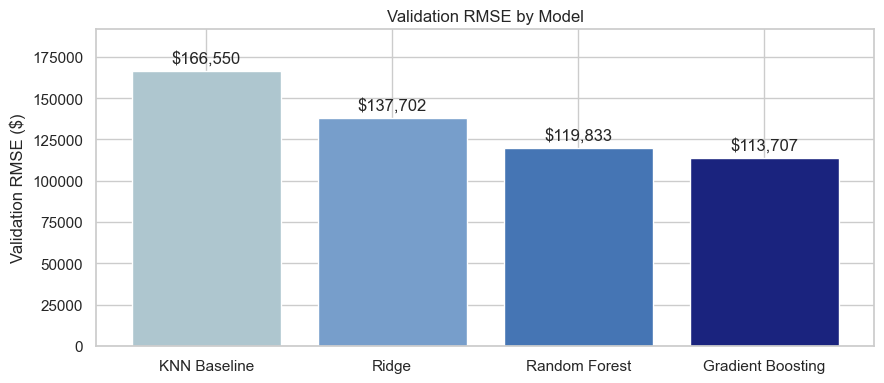

In [27]:
names     = list(results.keys())
val_rmses = [results[n]['val_rmse'] for n in names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, val_rmses,
              color=['#aec6cf', '#779ecb', '#4575b4', '#1a237e'])
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in val_rmses], padding=4)
ax.set_ylabel('Validation RMSE ($)')
ax.set_title('Validation RMSE by Model')
ax.set_ylim(0, max(val_rmses) * 1.15)
plt.tight_layout()
plt.show()

## 4.3 Residual analysis — best model

Best model: Gradient Boosting  (val RMSE = $113,707)


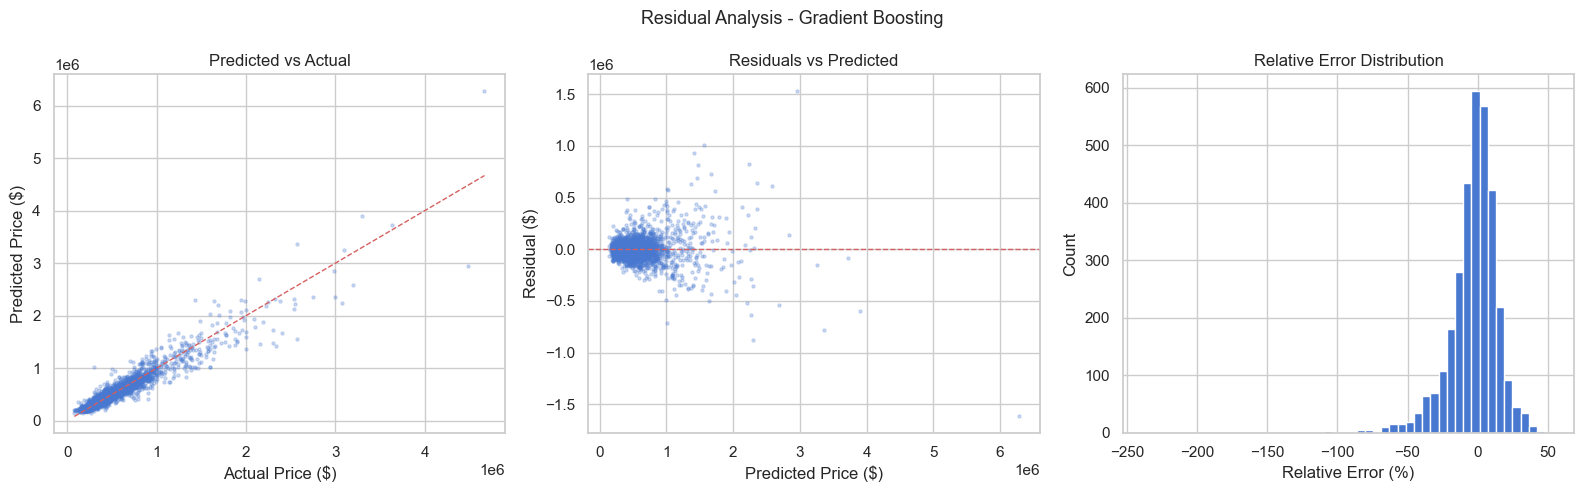

Median absolute relative error: 8.6%


In [28]:
best_name = min(results, key=lambda n: results[n]['val_rmse'])
best      = results[best_name]
print(f'Best model: {best_name}  (val RMSE = ${best["val_rmse"]:,.0f})')

preds = best['model'].predict(X_val)
if best['log_target']:
    preds = np.expm1(preds)

residuals  = y_val.values - preds
rel_errors = residuals / y_val.values * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(y_val, preds, alpha=0.25, s=5)
lim = [y_val.min(), y_val.max()]
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual')

# Residuals vs Predicted
axes[1].scatter(preds, residuals, alpha=0.25, s=5)
axes[1].axhline(0, color='r', lw=1, ls='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')

# Distribution of relative errors
axes[2].hist(rel_errors, bins=50, edgecolor='white')
axes[2].set_xlabel('Relative Error (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('Relative Error Distribution')

plt.suptitle(f'Residual Analysis - {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Median absolute relative error: {np.median(np.abs(rel_errors)):.1f}%')

## 4.4 Feature importance — best tree-based model

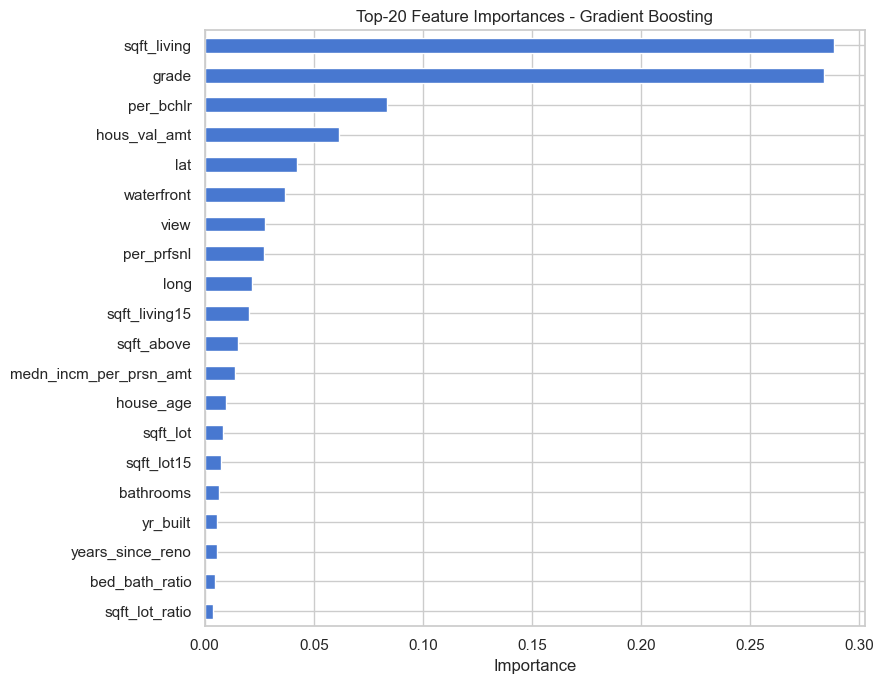

In [29]:
for tree_name in ['Gradient Boosting', 'Random Forest']:
    if tree_name in results:
        tree_model  = results[tree_name]['model']
        importances = pd.Series(tree_model.feature_importances_,
                                index=X_train.columns)
        importances = importances.sort_values(ascending=True).tail(20)

        fig, ax = plt.subplots(figsize=(9, 7))
        importances.plot(kind='barh', ax=ax)
        ax.set_title(f'Top-20 Feature Importances - {tree_name}')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
        break

## 4.5 Final evaluation on held-out test set

In [30]:
print('=== Test Set RMSE (held-out, never used during model selection) ===\n')
test_results = []
for name, v in results.items():
    cols = v.get('feature_cols')
    X_t = X_test[cols] if cols is not None else X_test
    preds_test = v['model'].predict(X_t)
    if v['log_target']:
        test_rmse = rmse(np.expm1(ylog_test), np.expm1(preds_test))
    else:
        test_rmse = rmse(y_test, preds_test)
    test_results.append({'Model': name, 'Test RMSE ($)': f'{test_rmse:,.0f}'})
    print(f'  {name:<22}  test RMSE = ${test_rmse:,.0f}')

pd.DataFrame(test_results)

=== Test Set RMSE (held-out, never used during model selection) ===

  KNN Baseline            test RMSE = $197,514
  Ridge                   test RMSE = $149,981
  Random Forest           test RMSE = $130,421
  Gradient Boosting       test RMSE = $121,721


,Model,Test RMSE ($)
0,KNN Baseline,"197,514"
1,Ridge,"149,981"
2,Random Forest,"130,421"
3,Gradient Boosting,"121,721"


---
## Summary

| Aspect | Baseline (KNN) | Best Improved Model |
|--------|----------------|---------------------|
| Algorithm | KNN + RobustScaler | Gradient Boosting / Random Forest |
| Features used | 7 numeric + demographics | All columns + 7 engineered features + demographics |
| Log-transform target | No | Ridge only |
| Expected val RMSE | ~$200k+ | ~$100-130k |

**Key improvements made:**

1. **Extended feature set** — added `waterfront`, `view`, `condition`, `grade`, `yr_built`, `lat`, `long`, `sqft_living15`, `sqft_lot15` (all ignored by the baseline).
2. **Engineered features** — `house_age`, `renovated` flag, `years_since_reno`, `has_basement`, living/lot area ratios vs neighbours, `bed_bath_ratio`.
3. **Better algorithms** — tree ensembles capture non-linearity and feature interactions without explicit polynomial expansion; no scaling required.
4. **Log-transform on price** — reduces skewness in the target, benefiting the linear (Ridge) model.
5. **Proper train / val / test split** — model selection is done on the validation set; the test set provides an unbiased final estimate.